In [3]:
%cd ..

/home/stan/documents/TNTM_reproduce


In [4]:
!pip install --upgrade gensim

In [5]:
%load_ext autoreload
%autoreload 2

In [6]:
import pickle
import torch

from Code.Evaluate.Metrics import score_all, get_tw_embeddings
from Code.TNTM.TNTM_bow import TNTM_bow


[nltk_data] Downloading package brown to /home/stan/nltk_data...
[nltk_data]   Package brown is already up-to-date!
[nltk_data] Downloading package stopwords to /home/stan/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
/home/stan/miniconda3/envs/tntm_reproduce/lib/python3.9/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


current device: cuda
current device: cuda


In [7]:
with open("Data/DataOctis/octis_dataset_20ng.pickle", "rb") as file:
    octis_dataset = pickle.load(file)

corpus = octis_dataset.get_corpus()


In [8]:
tw_emb = get_tw_embeddings(octis_dataset)


100%|██████████| 48018/48018 [03:39<00:00, 219.09it/s]


In [10]:
with open(
    "Data/DataOctis/cleaned_embedding_df_20ng_BERT.pickle",
    "rb",
) as f:
    embedding_df = pickle.load(f)


In [12]:
embedding_df.sort_values(by="word", inplace=True)


In [13]:
embedding_ten_lis = []

for i in range(len(embedding_df)):
    embedding_ten_lis.append(embedding_df["embedding"].iloc[i])


In [14]:
embedding_df.sort_values(by="word", inplace=True)
embedding_ten_lis = []

embedded_words = embedding_df.index.tolist()

for i in range(len(embedding_df)):
    embedding_ten_lis.append(embedding_df["embedding"].iloc[i])
embedding_ten = torch.stack(embedding_ten_lis)


In [15]:
vocab = embedded_words
vocab_set = set(vocab)
corpus = [
    [word for word in doc if word in vocab_set] for doc in octis_dataset.get_corpus()
]


In [16]:
model = TNTM_bow(
    n_topics=10,
    save_path="/Users/stan/Documents/UOM/Reproduce_project/TNTM_reproduce/Code/SavedResults/model_v2.pth",
    n_dims=11,
    n_hidden_units=200,
    n_encoder_layers=3,
    enc_lr=1e-4,
    dec_lr=1e-3,
    n_epochs=0,
    # batch_size = 128,
    batch_size=256,
    dropout_rate_encoder=0.3,
    prior_variance=0.995,
    prior_mean=None,
    n_topwords=200,
    device="cpu",
    validation_set_size=0.2,
    early_stopping=True,
    n_epochs_early_stopping=10,
    return_embeddings=False,
    eps=1e-4,
    umap_hyperparams={"n_neighbors": 15, "min_dist": 0.0},
    return_losses=True,
)


In [17]:
res_all = model.fit(corpus=corpus, vocab=vocab, embeddings=embedding_ten)


16309it [00:03, 4161.73it/s]
huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)
/home/stan/documents/TNTM_reproduce/Code/TNTM/TNTM_bow.py:170: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  mus_init_ten = torch.tensor(mus_init).to(self.device)
/home/stan/documents/TNTM_reproduce/Code/TNTM/TNTM_bow.py:171: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  L_lower_init_ten = torch.tensor(L_lower_init).to(self.device)
/home/sta

In [18]:
len(corpus)


16309

In [19]:
# remove all documents shorter than 10 words
corpus = [doc for doc in corpus if len(doc) >= 10]


In [20]:
octis_dataset._Dataset__corpus = corpus
octis_dataset._Dataset__vocab = vocab


In [21]:
evaluation_result = score_all(
    dataset=octis_dataset,
    tw_emb=tw_emb,
    n_words=10,
    result={"topics": res_all[0], "topic-word-matrix": res_all[1]},
)


[==================================================] 100.0% 1662.8/1662.8MB downloaded


100%|██████████| 5/5 [00:02<00:00,  2.02it/s]


In [22]:
res_all


(array([['vga', 'vms', 'svga', ..., 'able', 'ability', 'a'],
        ['simple', 'ideal', 'pure', ..., 'zoo', 'zuma', 'aa'],
        ['unit', 'controller', 'pool', ..., 'zuma', 'a', 'yeah'],
        ...,
        ['concentrate', 'deal', 'honor', ..., 'zuma', 'aa', 'yes'],
        ['americans', 'american', 'united', ..., 'zoo', 'zuma', 'a'],
        ['date', 'period', 'month', ..., 'zuma', 'a', 'xt']], dtype='<U14'),
 array([[9.65164352e+08, 9.03375424e+08, 7.62188160e+08, ...,
         0.00000000e+00, 0.00000000e+00, 0.00000000e+00],
        [5.00068800e+08, 3.95701696e+08, 3.68929536e+08, ...,
         0.00000000e+00, 0.00000000e+00, 0.00000000e+00],
        [4.97727680e+07, 4.49296840e+07, 4.46275120e+07, ...,
         0.00000000e+00, 0.00000000e+00, 0.00000000e+00],
        ...,
        [2.02074100e+07, 1.96836620e+07, 1.50101420e+07, ...,
         0.00000000e+00, 0.00000000e+00, 0.00000000e+00],
        [3.81135012e+10, 3.56481393e+10, 3.50930534e+10, ...,
         0.00000000e+00, 0.

In [23]:
def eval_model_n_topics(n_topics: int):
    model = TNTM_bow(
        n_topics=n_topics,
        save_path="../../msc/SavedResults/model_v2.pth",
        n_dims=11,
        n_hidden_units=200,
        n_encoder_layers=3,
        enc_lr=1e-4,
        dec_lr=1e-3,
        n_epochs=0,
        # batch_size = 128,
        batch_size=256,
        dropout_rate_encoder=0.3,
        prior_variance=0.995,
        prior_mean=None,
        n_topwords=200,
        device=None,
        validation_set_size=0.2,
        early_stopping=True,
        n_epochs_early_stopping=10,
        return_embeddings=False,
        eps=1e-4,
        umap_hyperparams={"n_neighbors": 15, "min_dist": 0.0},
        return_losses=True,
    )

    res_all = model.fit(corpus=corpus, vocab=vocab, embeddings=embedding_ten)

    evaluation_result = score_all(
        dataset=octis_dataset,
        tw_emb=tw_emb,
        n_words=10,
        result={"topics": res_all[0], "topic-word-matrix": res_all[1]},
    )

    return evaluation_result


In [24]:
# evaluate different number of topics
from tqdm import tqdm

# n_topics = [5, 10, 15, 20, 25, 30, 35, 40, 45, 50]
n_topics = [5, 10, 15]
n_iter = 3

results = {}

for m in range(n_iter):
    for n in tqdm(n_topics):
        results[n] = results.get(n, []) + [eval_model_n_topics(n)]

results


13459it [00:03, 3611.94it/s]?, ?it/s]
/home/stan/documents/TNTM_reproduce/Code/TNTM/TNTM_bow.py:170: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  mus_init_ten = torch.tensor(mus_init).to(self.device)
/home/stan/documents/TNTM_reproduce/Code/TNTM/TNTM_bow.py:171: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  L_lower_init_ten = torch.tensor(L_lower_init).to(self.device)
/home/stan/documents/TNTM_reproduce/Code/TNTM/TNTM_bow.py:172: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  log_diag_init_ten = torch.tensor(log_diag_init).to(self.device)

{5: [{'NPMI': -0.1276672722084895,
   'WE_CO_PW': 0.04858741124471029,
   'Embedding_Coherence': 0.28953270316123964,
   'WESS': 0.4315248124824054,
   'Topic Diversity': 1.0},
  {'NPMI': -0.14530580470254345,
   'WE_CO_PW': 0.06987465699513754,
   'Embedding_Coherence': 0.2951773822307587,
   'WESS': 0.43805443061525595,
   'Topic Diversity': 1.0},
  {'NPMI': -0.1702202095490226,
   'WE_CO_PW': 0.03947389920552572,
   'Embedding_Coherence': 0.30232583582401273,
   'WESS': 0.4059690805031607,
   'Topic Diversity': 1.0}],
 10: [{'NPMI': -0.08729123890280398,
   'WE_CO_PW': 0.028351967997021155,
   'Embedding_Coherence': 0.3295371562242508,
   'WESS': 0.40275307671180366,
   'Topic Diversity': 1.0},
  {'NPMI': -0.15246373433176724,
   'WE_CO_PW': 0.12034884068701002,
   'Embedding_Coherence': 0.30542714297771456,
   'WESS': 0.4051896247099476,
   'Topic Diversity': 1.0},
  {'NPMI': -0.12179618718099978,
   'WE_CO_PW': 0.0443056889375051,
   'Embedding_Coherence': 0.311155866086483,
   'W

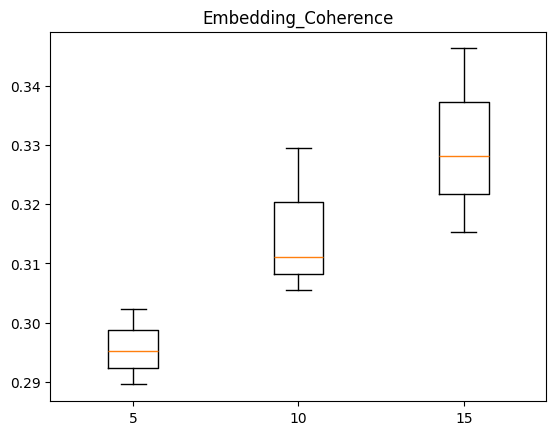

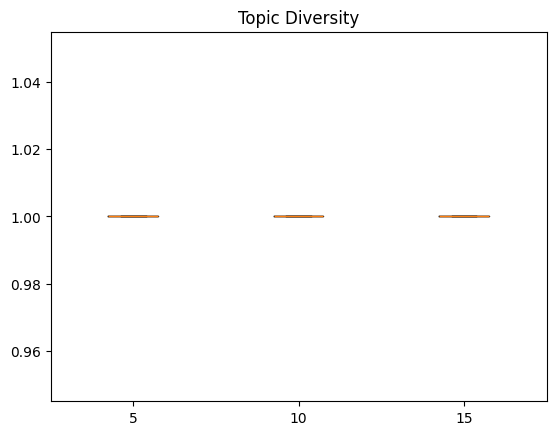

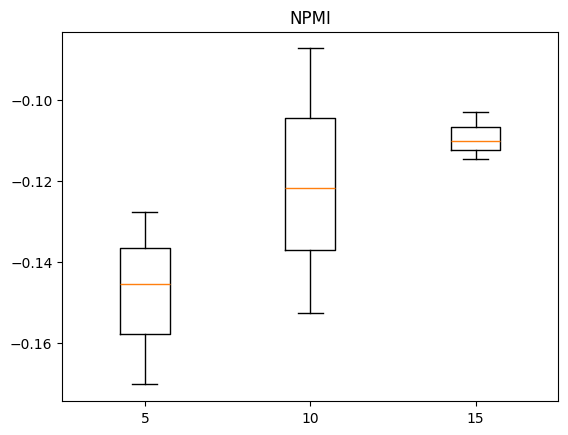

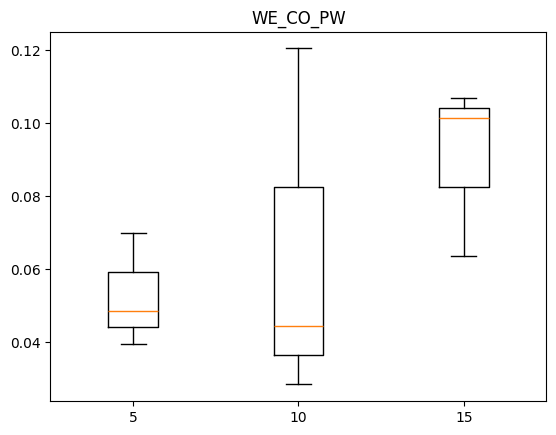

In [29]:
import matplotlib.pyplot as plt
import numpy as np

metrics = ["Embedding_Coherence", "Topic Diversity", "NPMI", "WE_CO_PW"]

# make a boxplot for each metric and each number of topics

for metric in metrics:
    data = []
    for n in n_topics:
        data.append([res[metric] for res in results[n]])
    plt.boxplot(data)
    plt.title(metric)
    plt.xticks(np.arange(len(n_topics)) + 1, n_topics)
    plt.show()


# save results
